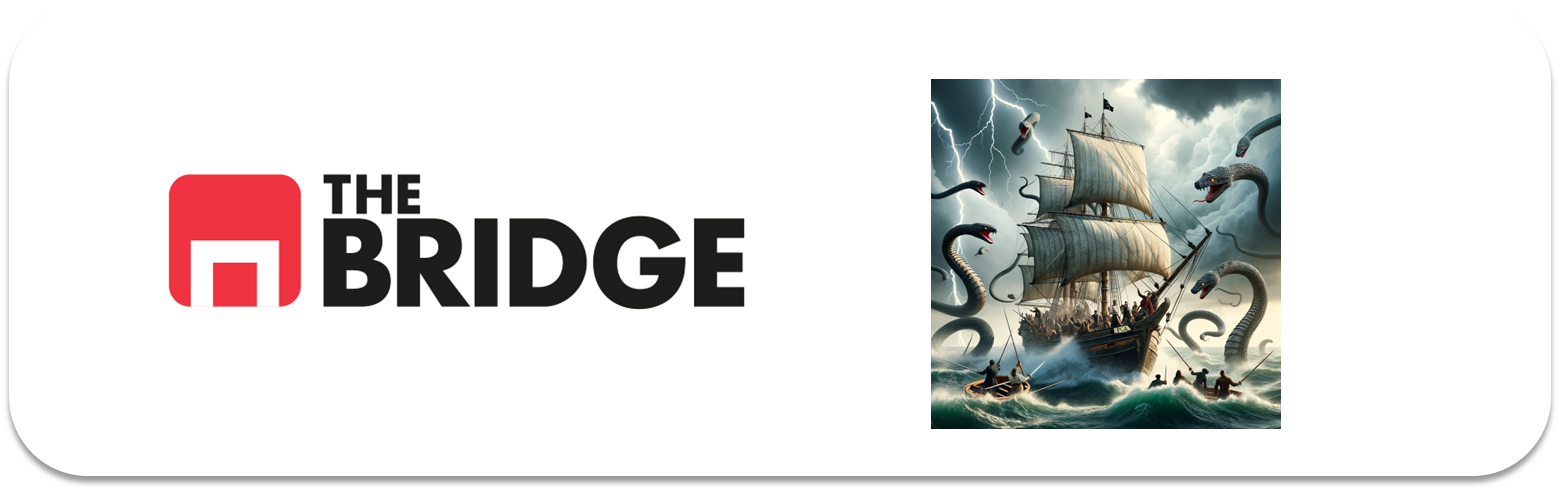

## PRACTICA OBLIGATORIA: **Seleccion Features**

* La práctica obligatoria de esta unidad consiste en hacer una comparativa de diferentes técnicas de selección de features sobre un dataset ya conocido. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Descripción General y Objetivo

El objetivo de la práctica es que juegues con las diferentes técncias de selección de features sobre un problema de clasificación. Para ello, tendrás que cargar el dataset de credit scoring que tienes en la carpeta "data" y que ya hemos trabajado anteriormente. A partir de ahí tendrás que probar diferentes técnicas de selección de features y compararlas todas entre sí y escoger finalmente el conjunto más sencillo con más potencia. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

### Detalles e Instrucciones

El objetivo es que construyas un modelo final de clasificació sobre la variable "SeriousDlqin2yrs" del dataset que encontrarás en "data".  

Sigue los pasos del proceso de ML que hemos aprendido para problemas supervisados con el dataset que encontrarás en "data" pero con las siguiente salvedades:

1. Deshazte de las filas con nulos, para este ejercicio no nos importan. Convierte las features NumberOf... que creas conveniente a categóricas con 2 o 3 niveles a lo sumo.

2. A la hora de hacer el miniEda aplica los siguientes análisis y selección de features: 
    1. Análisis visual combinado con filtrado por valores de correlación y umbral de covarianza.
    2. Selección de features numéricas mediante SelectKBest y ANOVA, selecció de features categóricas mediante Mutual Information 
    3. Selección de las mejores features a través de un modelo intermedio (usando SelectFromModel)
    4. Selección de las mejores features empleando RFE.
    5. Selección de las mejores features empleando SFS.
    6. Selección de las mejores features mediante un sistema de hard-voting aplicado a lo obtenido en los pasos 1 a 5 anteriores.

    Para cada paso anterior (salvo el 1) se pide obtener una lista de features de "primera división" con un número de variables no superior a 6 (pueden ser menos).

3. Escoge tres modelos y a la hora compararlos para escoger el mejor, entrenalos con validación cruzada empleando las seis listas obtenidas anteriormente. Es decir tendrás 18 (6*3) medidas (emplea la métrica que creas más conveniente y si no se te ocurre ninguna el recall medio).  Escoge el mejor modelo y la mejor selección de features.

4. Optimiza los hiperparámetros del mejor modelo. Evalúalo contra test.


In [4]:
df = pd.read_csv('./data/credit_npo.csv')
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0.0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0.0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2.0
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3.0
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12537 entries, 0 to 12536
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      12537 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  12537 non-null  float64
 2   age                                   12537 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  12537 non-null  int64  
 4   DebtRatio                             12537 non-null  float64
 5   MonthlyIncome                         11816 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       12537 non-null  int64  
 7   NumberOfTimes90DaysLate               12537 non-null  int64  
 8   NumberRealEstateLoansOrLines          12537 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  12537 non-null  int64  
 10  NumberOfDependents                    12360 non-null  float64
dtypes: float64(4), 

In [6]:
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11816 entries, 0 to 12536
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      11816 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  11816 non-null  float64
 2   age                                   11816 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  11816 non-null  int64  
 4   DebtRatio                             11816 non-null  float64
 5   MonthlyIncome                         11816 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       11816 non-null  int64  
 7   NumberOfTimes90DaysLate               11816 non-null  int64  
 8   NumberRealEstateLoansOrLines          11816 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  11816 non-null  int64  
 10  NumberOfDependents                    11816 non-null  float64
dtypes: float64(4), int64

In [7]:
target = 'SeriousDlqin2yrs'
df[target].value_counts()

SeriousDlqin2yrs
0    10986
1      830
Name: count, dtype: int64

In [8]:
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,11816.000000,11816.000000,11816.000000,11816.000000,11816.000000,11816.000000,11816.000000,11816.000000,11816.000000,11816.000000,11816.000000
mean,0.070244,0.335668,51.447698,0.340471,0.499708,6864.815420,8.759140,0.180010,1.059580,0.149712,0.856804
std,0.255568,0.365209,14.516270,2.927409,2.696067,11855.905437,5.129772,2.892577,1.140716,2.868248,1.147509
min,0.000000,0.000000,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.034927,41.000000,0.000000,0.143456,3498.750000,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.179183,51.000000,0.000000,0.294748,5416.000000,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.587187,62.000000,0.000000,0.477414,8300.000000,11.000000,0.000000,2.000000,0.000000,2.000000
max,1.000000,6.000000,101.000000,98.000000,96.000000,702500.000000,49.000000,98.000000,19.000000,98.000000,10.000000


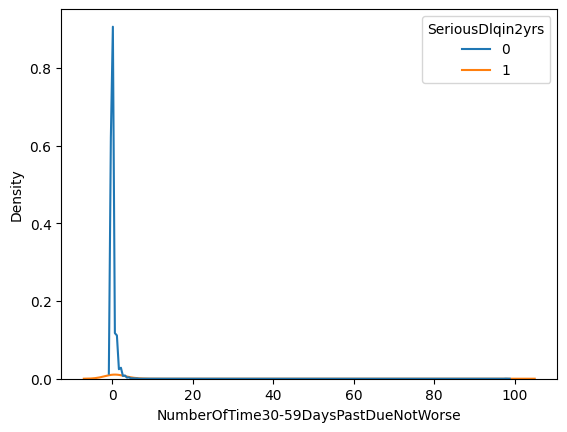

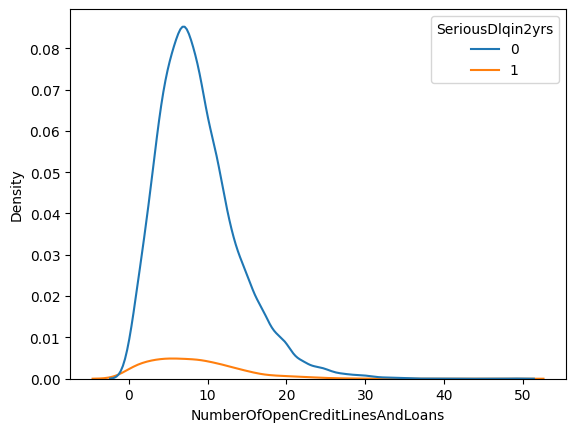

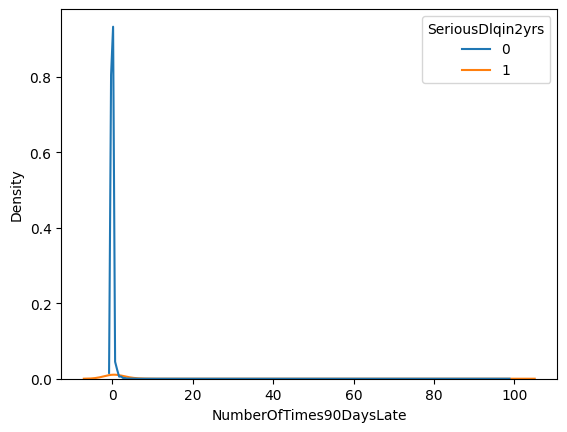

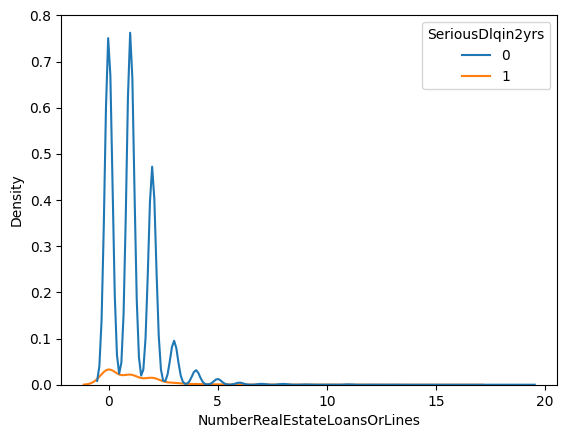

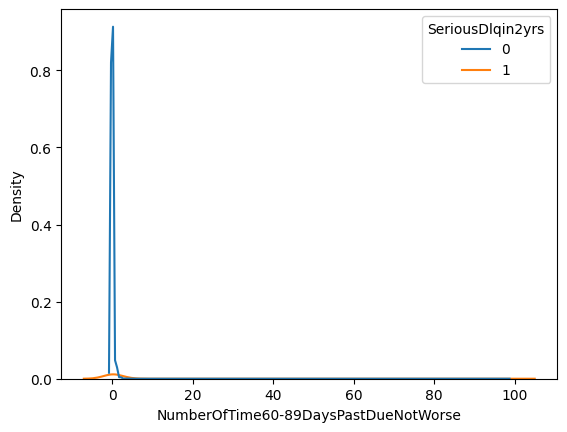

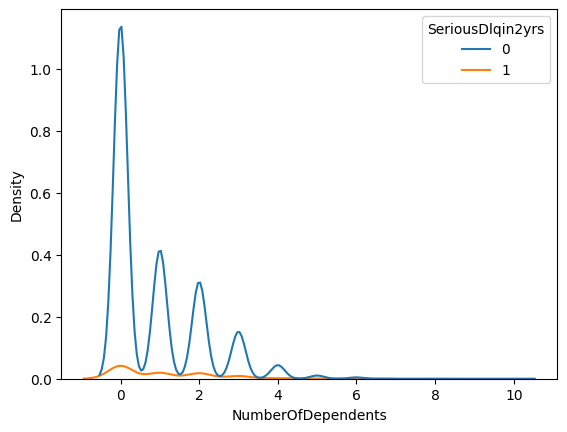

In [9]:
for col in df.columns:
    if col.startswith('Number'):
        sns.kdeplot(df, x=col, hue=target)
        plt.show()

In [10]:
df['NumberOfTime30-59DaysPastDueNotWorse'] = df['NumberOfTime30-59DaysPastDueNotWorse'] != 0
df['NumberOfTimes90DaysLate'] = df['NumberOfTimes90DaysLate'] != 0
df['NumberOfTime60-89DaysPastDueNotWorse'] = df['NumberOfTime60-89DaysPastDueNotWorse'] != 0

In [11]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.2, random_state=42, stratify=df[target])

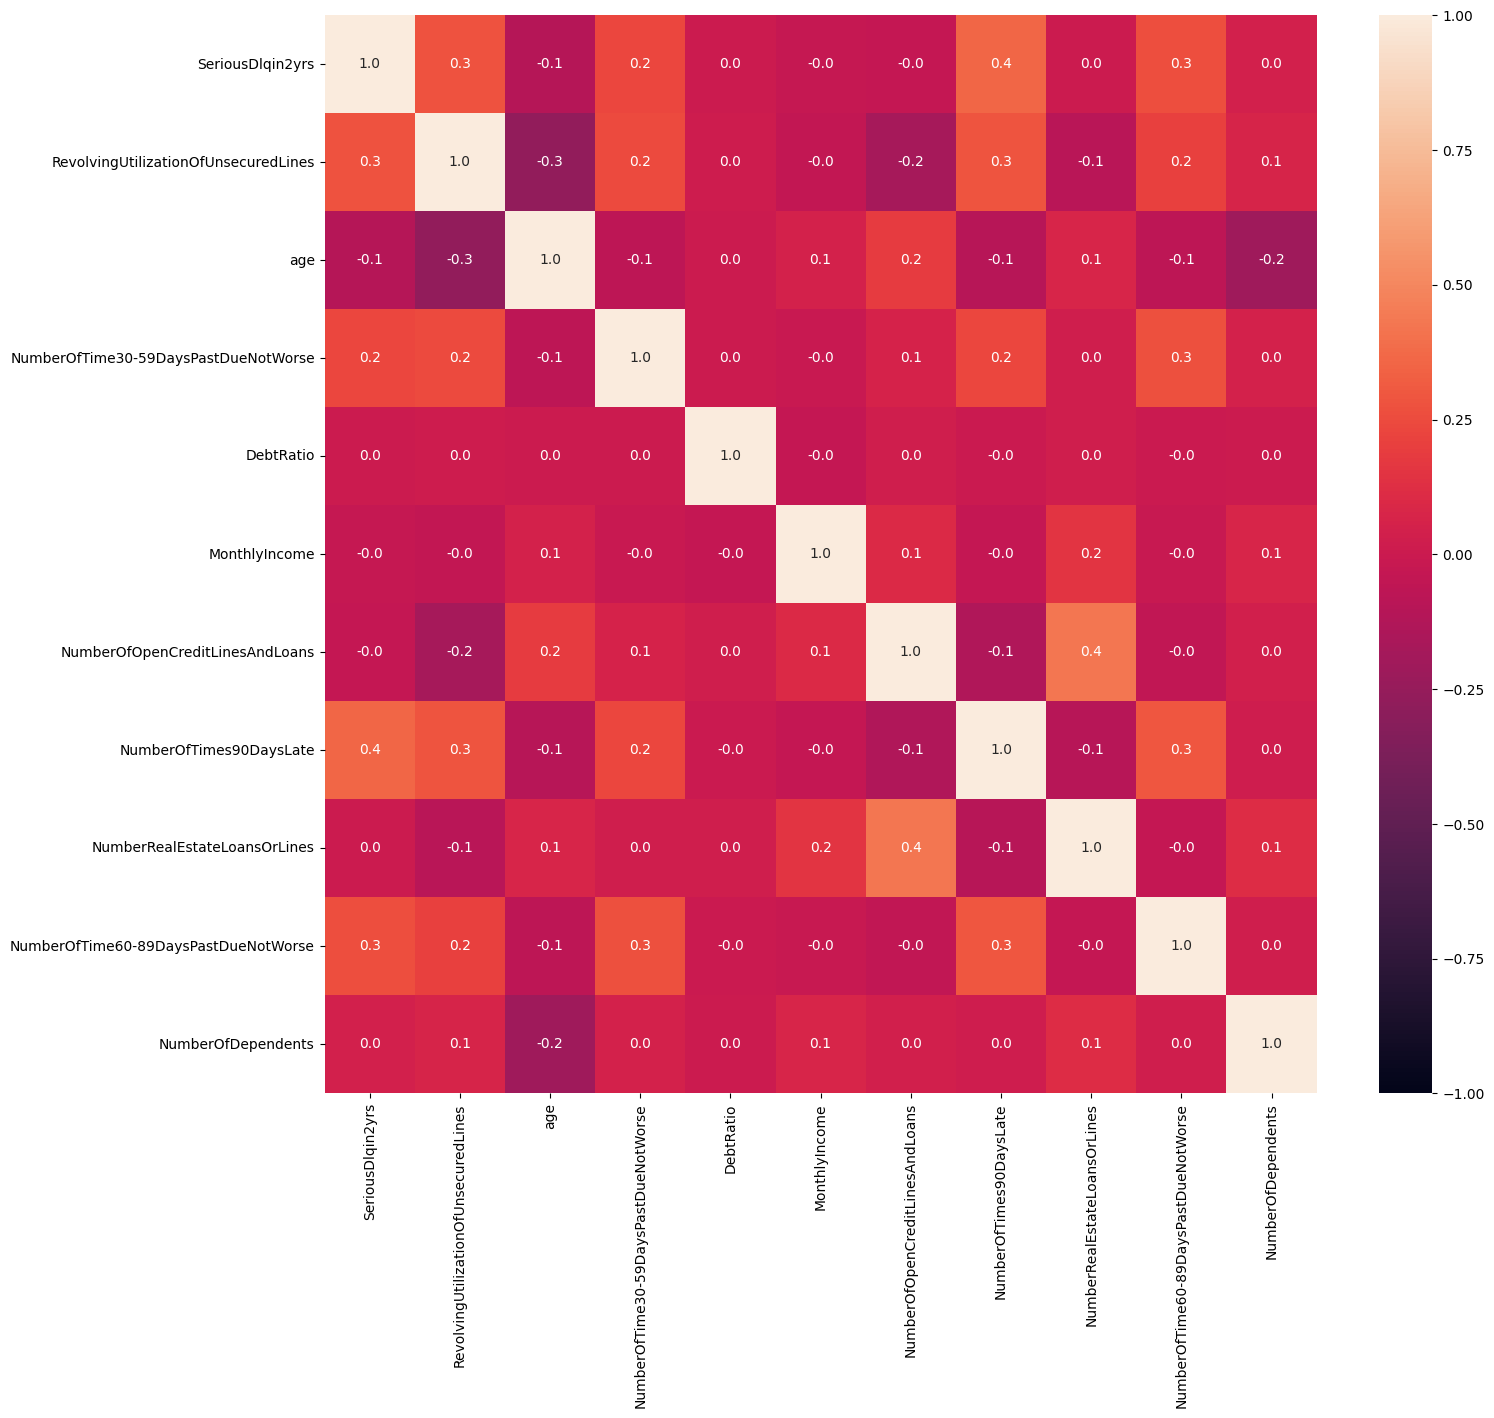

In [12]:
_ = plt.figure(figsize=(16, 14))
sns.heatmap(train.corr(), vmin=-1, annot=True, fmt='.1f')
plt.show()

In [13]:
train.columns

Index(['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')

In [14]:
features_cat = ['NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 'NumberOfTime60-89DaysPastDueNotWorse']
features_num = ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines', 'NumberOfDependents']

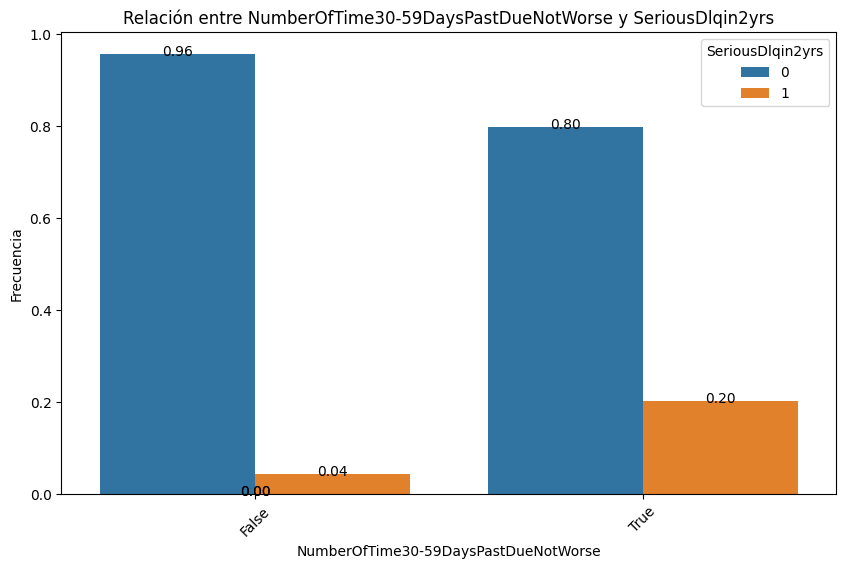

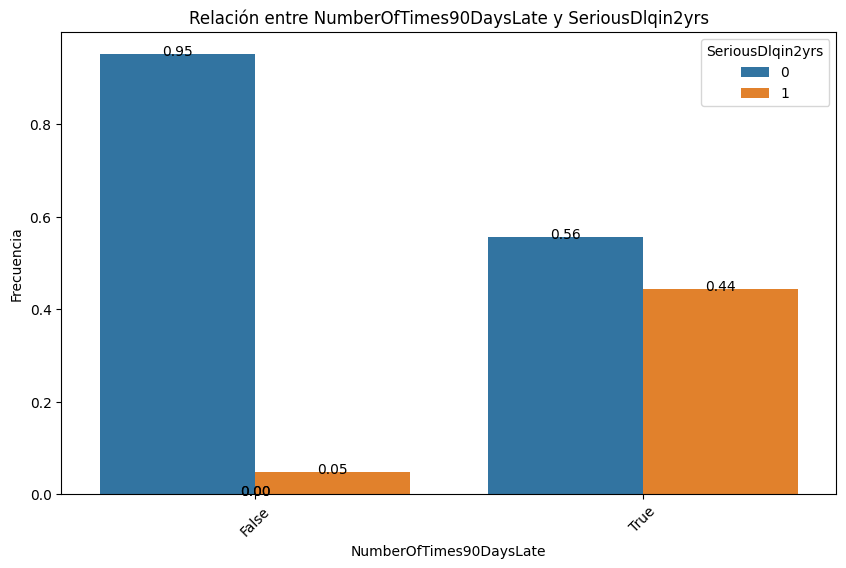

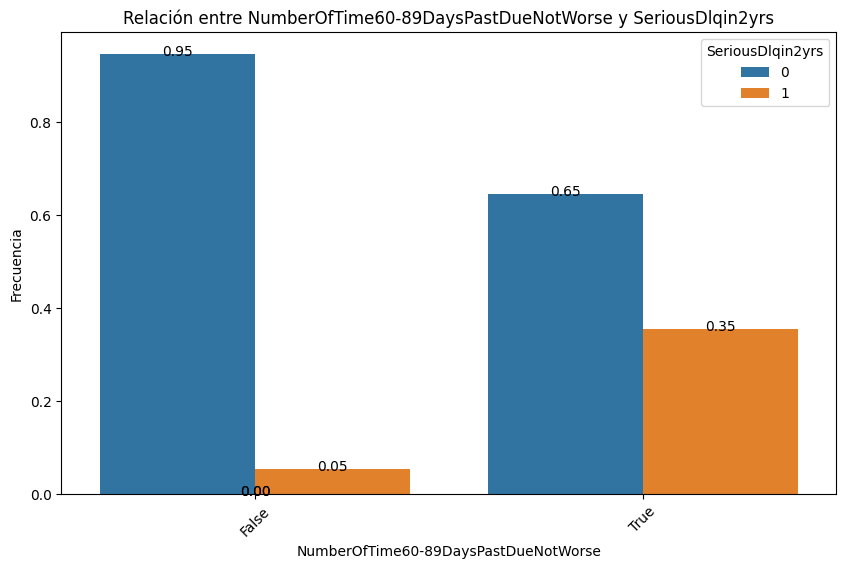

In [15]:
from bootcampviztools import plot_categorical_relationship_fin

for col in features_cat:
    plot_categorical_relationship_fin(train, col, target, True, True, 2)

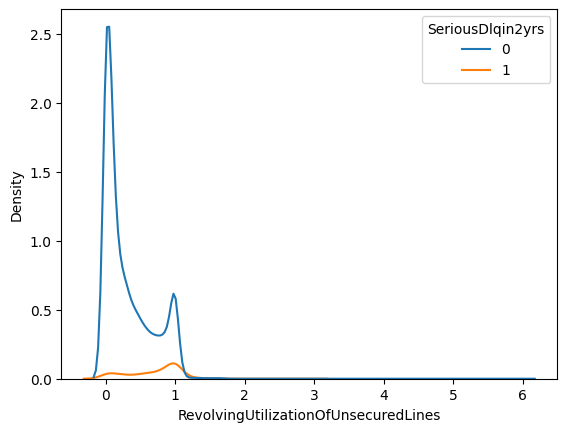

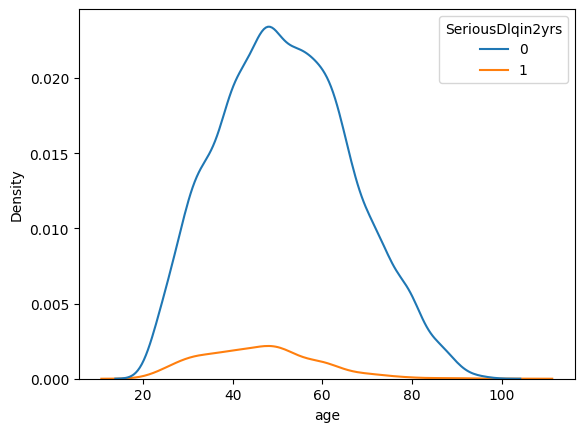

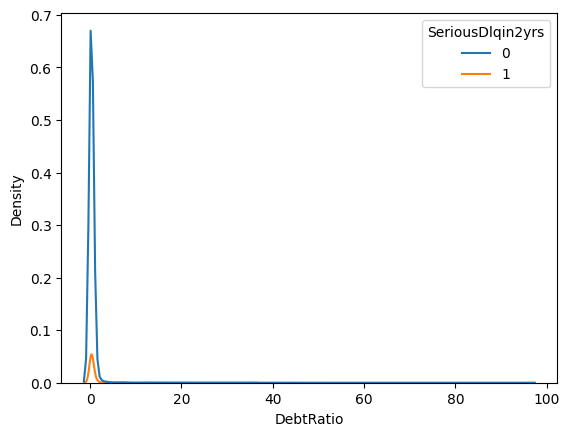

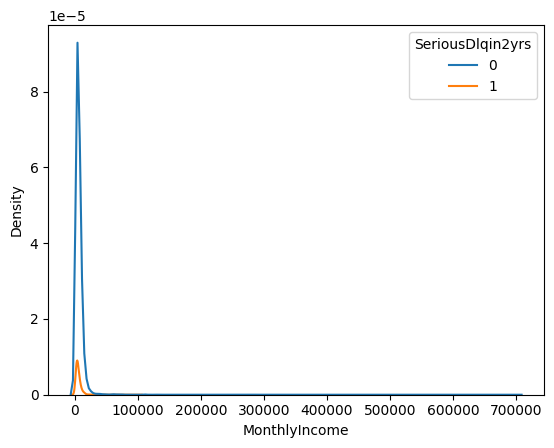

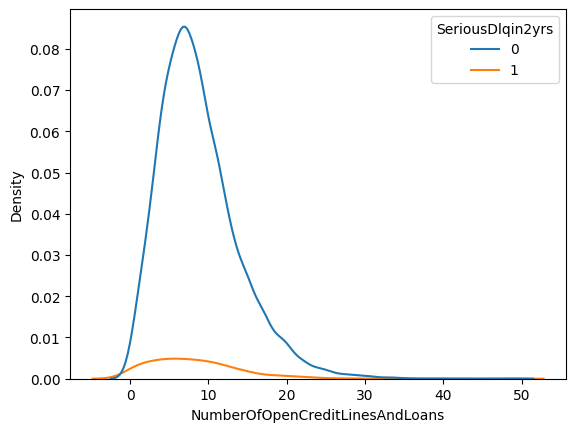

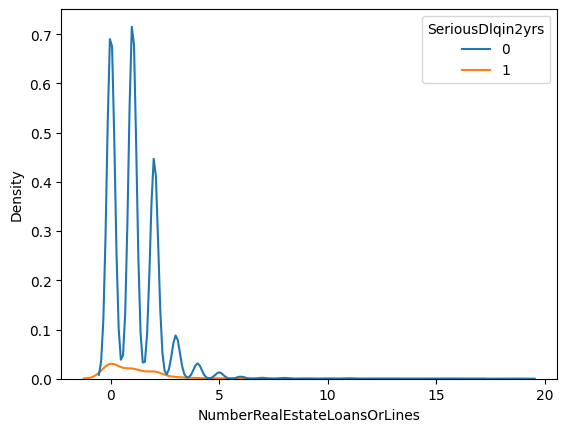

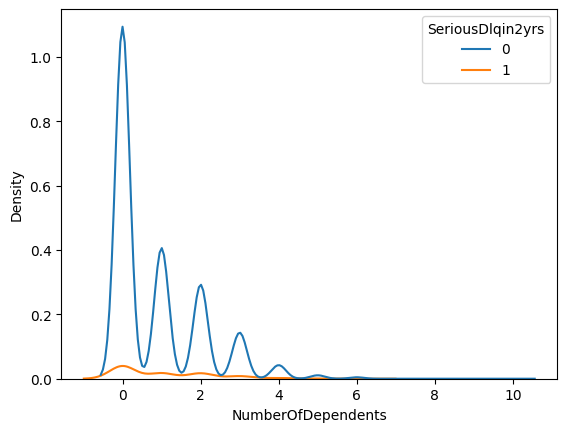

In [16]:
for col in features_num:
    sns.kdeplot(train, x=col, hue=target)
    plt.show()

In [17]:
train.columns

Index(['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')

In [18]:
features = {'caso_1': ['RevolvingUtilizationOfUnsecuredLines', 'NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 'NumberOfTime60-89DaysPastDueNotWorse']}

In [19]:
from sklearn.metrics import mutual_info_score

for col in features_cat:
    print(f"MI({col};{target}):", mutual_info_score(train[col], train[target]))

MI(NumberOfTime30-59DaysPastDueNotWorse;SeriousDlqin2yrs): 0.020831100086090043
MI(NumberOfTimes90DaysLate;SeriousDlqin2yrs): 0.03315981105348048
MI(NumberOfTime60-89DaysPastDueNotWorse;SeriousDlqin2yrs): 0.019220687427717945


In [21]:
from sklearn.feature_selection import SelectKBest, f_classif

'''
f_classif realiza un test ANOVA
a técnica de análisis de varianza (ANOVA) también conocida como análisis factorial y desarrollada por Fisher en 1930,
constituye la herramienta básica para el estudio del efecto de uno o más factores (cada uno con dos o más niveles) sobre
la media de una variable continua. Es por lo tanto el test estadístico a emplear cuando se desea comparar las medias de
dos o más grupos.
'''

selector = SelectKBest(f_classif, k=6)
x_data_kbest = selector.fit_transform(train.drop(columns=target), train[target])
X_train_kbest = pd.DataFrame(x_data_kbest, columns = selector.get_feature_names_out())
X_train_kbest

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTimes90DaysLate,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0.039187,61.0,0.0,0.0,0.0,0.0
1,0.919317,41.0,0.0,0.0,0.0,0.0
2,0.253718,49.0,0.0,0.0,0.0,0.0
3,0.249462,26.0,0.0,0.0,0.0,0.0
4,0.224520,76.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...
9447,0.174437,61.0,0.0,0.0,0.0,0.0
9448,0.039651,64.0,0.0,0.0,0.0,0.0
9449,1.000000,29.0,0.0,0.0,0.0,6.0
9450,0.945805,51.0,1.0,0.0,0.0,0.0


In [24]:
features['caso_2'] = X_train_kbest.columns.tolist()

In [30]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier

rf_cl = RandomForestClassifier(max_depth=5, random_state=42)

selector_model = SelectFromModel(estimator=rf_cl)
selector_model.fit(train.drop(columns=target), train[target])
selector_model.get_feature_names_out()

array(['RevolvingUtilizationOfUnsecuredLines', 'NumberOfTimes90DaysLate',
       'NumberOfTime60-89DaysPastDueNotWorse'], dtype=object)

In [33]:
features['caso_3'] = selector_model.get_feature_names_out().tolist()

In [41]:
from sklearn.feature_selection import RFE

rfe = RFE(estimator=rf_cl, n_features_to_select=6, step=1)

rfe.fit(train.drop(columns=target), train[target])
rfe_df = pd.DataFrame(rfe.ranking_, columns= ["ranking"], index=train.drop(columns=target).columns).sort_values("ranking")

In [43]:
features['caso_4'] = rfe_df[rfe_df['ranking'] == 1].index.tolist()

In [44]:
from sklearn.feature_selection import SequentialFeatureSelector

sfs_forward = SequentialFeatureSelector(rf_cl, n_features_to_select=6, cv=5, scoring="balanced_accuracy")

sfs_forward.fit(train.drop(columns=target), train[target])

print("Elegidasd SFS:", sfs_forward.get_feature_names_out())

Elegidasd SFS: ['RevolvingUtilizationOfUnsecuredLines'
 'NumberOfTime30-59DaysPastDueNotWorse' 'DebtRatio'
 'NumberOfTimes90DaysLate' 'NumberRealEstateLoansOrLines'
 'NumberOfTime60-89DaysPastDueNotWorse']


In [48]:
features['caso_5'] = sfs_forward.get_feature_names_out().tolist()

In [69]:
features_voting = {col: 0 for col in train.columns}

for val in features.values():
    for col in val:
        features_voting[col] += 1

features_voting

{'SeriousDlqin2yrs': 0,
 'RevolvingUtilizationOfUnsecuredLines': 5,
 'age': 1,
 'NumberOfTime30-59DaysPastDueNotWorse': 4,
 'DebtRatio': 2,
 'MonthlyIncome': 0,
 'NumberOfOpenCreditLinesAndLoans': 1,
 'NumberOfTimes90DaysLate': 5,
 'NumberRealEstateLoansOrLines': 1,
 'NumberOfTime60-89DaysPastDueNotWorse': 5,
 'NumberOfDependents': 1}

In [74]:
features_sorted = sorted(features_voting.items(), key=lambda x: x[1], reverse=True)
features_sorted

[('RevolvingUtilizationOfUnsecuredLines', 5),
 ('NumberOfTimes90DaysLate', 5),
 ('NumberOfTime60-89DaysPastDueNotWorse', 5),
 ('NumberOfTime30-59DaysPastDueNotWorse', 4),
 ('DebtRatio', 2),
 ('age', 1),
 ('NumberOfOpenCreditLinesAndLoans', 1),
 ('NumberRealEstateLoansOrLines', 1),
 ('NumberOfDependents', 1),
 ('SeriousDlqin2yrs', 0),
 ('MonthlyIncome', 0)]

In [78]:
features['caso_6'] = [f[0] for f in features_sorted[:5]]
features

{'caso_1': ['RevolvingUtilizationOfUnsecuredLines',
  'NumberOfTime30-59DaysPastDueNotWorse',
  'NumberOfTimes90DaysLate',
  'NumberOfTime60-89DaysPastDueNotWorse'],
 'caso_2': ['RevolvingUtilizationOfUnsecuredLines',
  'age',
  'NumberOfTime30-59DaysPastDueNotWorse',
  'NumberOfTimes90DaysLate',
  'NumberOfTime60-89DaysPastDueNotWorse',
  'NumberOfDependents'],
 'caso_3': ['RevolvingUtilizationOfUnsecuredLines',
  'NumberOfTimes90DaysLate',
  'NumberOfTime60-89DaysPastDueNotWorse'],
 'caso_4': ['RevolvingUtilizationOfUnsecuredLines',
  'NumberOfTime30-59DaysPastDueNotWorse',
  'DebtRatio',
  'NumberOfOpenCreditLinesAndLoans',
  'NumberOfTimes90DaysLate',
  'NumberOfTime60-89DaysPastDueNotWorse'],
 'caso_5': ['RevolvingUtilizationOfUnsecuredLines',
  'NumberOfTime30-59DaysPastDueNotWorse',
  'DebtRatio',
  'NumberOfTimes90DaysLate',
  'NumberRealEstateLoansOrLines',
  'NumberOfTime60-89DaysPastDueNotWorse'],
 'caso_6': ['RevolvingUtilizationOfUnsecuredLines',
  'NumberOfTimes90DaysLate

In [108]:
X_train = train.drop(columns=target)
y_train = train[target]

X_test = test.drop(columns=target)
y_test = test[target]

In [88]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score

model = {'RandomForestClassifier': RandomForestClassifier(max_depth=5, random_state=42),
         'XGBClassifier': XGBClassifier(max_depth=5, random_state=42),
         'LGBMClassifier': LGBMClassifier(max_depth=5, random_state=42, verbosity=-1),
}

salida = {k: [] for k in model.keys()}
for k1, mod in model.items():
    for fea in features.values():
        salida[k1].append(np.mean(cross_val_score(mod, X_train[fea], y_train, scoring='balanced_accuracy')))

pd.DataFrame(salida, index=features.keys())

,RandomForestClassifier,XGBClassifier,LGBMClassifier
caso_1,0.585322,0.599515,0.599638
caso_2,0.558002,0.587752,0.582196
caso_3,0.567697,0.592034,0.585152
caso_4,0.563509,0.604270,0.598161
caso_5,0.565446,0.604743,0.592773
caso_6,0.580206,0.610832,0.593753


*Me quedo con XGBClassifier para el caso_6 (hard-voting de las anteriores)*

In [89]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [200, 300, 400],
    'learning_rate': [0.01, 0.001],
    'max_depth': [4, 6, 8],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'scale_pos_weight': [len(train[train[target] == 0])/len(train[train[target] == 1]), 1],
}

grid = GridSearchCV(XGBClassifier(random_state=42), param_grid=param_grid, scoring='balanced_accuracy', verbose=1)

grid.fit(X_train[features['caso_6']], y_train)

c:\Users\phbas\Documents\Bootcamp_Data_Science\DS_Online_PedroHBas\venv\Lib\site-packages\numpy\ma\core.py:2896: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


GridSearchCV(estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     lea...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.01, 0.001], 'max_depth': [4, 6, 8],
                         'n_estimators': [200, 300, 400],
                         'scale_pos_weight': [13.234939759036145, 1],
                         'subsample': [0.8, 1.0]},
             scoring='balanced_accuracy')

In [92]:
pd.DataFrame(grid.cv_results_).sort_values('rank_test_score').head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_colsample_bytree,param_learning_rate,param_max_depth,param_n_estimators,param_scale_pos_weight,param_subsample,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
8,0.125953,0.011326,0.004105,0.000198,0.8,0.010,4,400,13.23494,0.8,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",0.762236,0.738010,0.747233,0.772294,0.763173,0.756589,0.012285,1
9,0.121929,0.005322,0.004240,0.000692,0.8,0.010,4,400,13.23494,1.0,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",0.760307,0.745084,0.745514,0.766318,0.764596,0.756364,0.009245,2
44,0.121474,0.003544,0.003880,0.000863,0.8,0.001,4,400,13.23494,0.8,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",0.759516,0.741324,0.750905,0.761525,0.765285,0.755711,0.008603,3
0,0.067082,0.005275,0.003104,0.000489,0.8,0.010,4,200,13.23494,0.8,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",0.757525,0.743439,0.737369,0.766768,0.772519,0.755524,0.013378,4
5,0.079448,0.001931,0.003812,0.000740,0.8,0.010,4,300,13.23494,1.0,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",0.749784,0.742302,0.741157,0.773208,0.770976,0.755485,0.013897,5


In [93]:
from sklearn.metrics import classification_report

print(classification_report(y_test, grid.predict(X_test[features['caso_6']])))

              precision    recall  f1-score   support

           0       0.97      0.78      0.87      2198
           1       0.20      0.71      0.31       166

    accuracy                           0.78      2364
   macro avg       0.59      0.75      0.59      2364
weighted avg       0.92      0.78      0.83      2364



### EXTRA

Aplica la PCA como método de selección, escoge un número de componentes en función de la varianza explicada y crea un dataset con el que entrenar el mismo tipo de modelo ganador de la parte general. Entrenalo y evalúalo contra test, comenta el resultado.

In [101]:
from sklearn.decomposition import PCA 

pca = PCA()
pca.fit(X_train)

PCA()

------------------------------------------
Porcentaje de varianza explicada acumulada
------------------------------------------
[0.99999848 0.99999978 0.99999994 0.99999998 0.99999999 1.
 1.         1.         1.         1.        ]


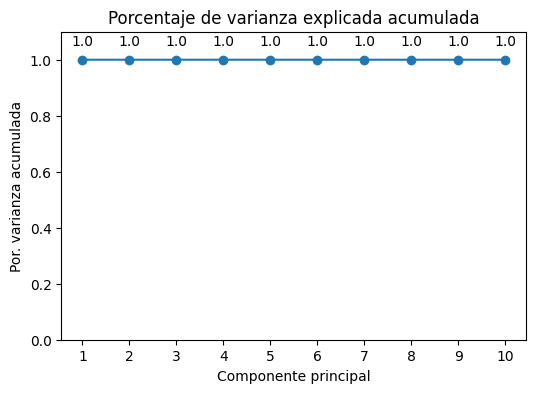

In [102]:
# Porcentaje de varianza explicada acumulada
# ==============================================================================
prop_varianza_acum = pca.explained_variance_ratio_.cumsum()
print('------------------------------------------')
print('Porcentaje de varianza explicada acumulada')
print('------------------------------------------')
print(prop_varianza_acum)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))
ax.plot(
    np.arange(len(X_train.columns)) + 1,
    prop_varianza_acum,
    marker = 'o'
)

for x, y in zip(np.arange(len(X_train.columns)) + 1, prop_varianza_acum):
    label = round(y, 2)
    ax.annotate(
        label,
        (x,y),
        textcoords="offset points",
        xytext=(0,10),
        ha='center'
    )
    
ax.set_ylim(0, 1.1)
ax.set_xticks(np.arange(pca.n_components_) + 1)
ax.set_title('Porcentaje de varianza explicada acumulada')
ax.set_xlabel('Componente principal')
ax.set_ylabel('Por. varianza acumulada');

In [109]:
pca_1 = PCA(1)

X_train_pca = pca_1.fit_transform(X_train)
X_test_pca = pca_1.transform(X_test)

In [104]:
param_grid = {
    'n_estimators': [200, 300, 400],
    'learning_rate': [0.01, 0.001],
    'max_depth': [4, 6, 8],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'scale_pos_weight': [len(train[train[target] == 0])/len(train[train[target] == 1]), 1],
}

grid = GridSearchCV(XGBClassifier(random_state=42), param_grid=param_grid, scoring='balanced_accuracy', verbose=1)

grid.fit(X_train_pca, y_train)

Fitting 5 folds for each of 144 candidates, totalling 720 fits


GridSearchCV(estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     lea...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.01, 0.001], 'max_depth': [4, 6, 8],
                         'n_estimators': [200, 300, 400],
                         'scale_pos_weight': [13.234939759036145, 1],
                         'subsample': [0.8, 1.0]},
             scoring='balanced_accuracy', verbose=1)

In [105]:
pd.DataFrame(grid.cv_results_).sort_values('rank_test_score').head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_colsample_bytree,param_learning_rate,param_max_depth,param_n_estimators,param_scale_pos_weight,param_subsample,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
45,0.094945,0.009777,0.003203,7.489909e-04,0.8,0.001,4,400,13.23494,1.0,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",0.549501,0.553968,0.559805,0.578828,0.576027,0.563626,0.011767,1
117,0.103115,0.006955,0.003212,3.962309e-04,1.0,0.001,4,400,13.23494,1.0,"{'colsample_bytree': 1.0, 'learning_rate': 0.0...",0.549501,0.553968,0.559805,0.578828,0.576027,0.563626,0.011767,1
108,0.055635,0.000837,0.001802,9.807177e-04,1.0,0.001,4,200,13.23494,0.8,"{'colsample_bytree': 1.0, 'learning_rate': 0.0...",0.546248,0.563576,0.559430,0.562307,0.582183,0.562749,0.011505,3
36,0.060789,0.005668,0.002800,4.033630e-04,0.8,0.001,4,200,13.23494,0.8,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",0.546248,0.563576,0.559430,0.562307,0.582183,0.562749,0.011505,3
40,0.079324,0.002743,0.003003,1.784161e-07,0.8,0.001,4,300,13.23494,0.8,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",0.546248,0.561239,0.553185,0.563670,0.582812,0.561431,0.012334,5


In [110]:
print(classification_report(y_test, grid.predict(X_test_pca)))

              precision    recall  f1-score   support

           0       0.94      0.58      0.72      2198
           1       0.08      0.51      0.14       166

    accuracy                           0.57      2364
   macro avg       0.51      0.54      0.43      2364
weighted avg       0.88      0.57      0.68      2364

